# 02 Growth Metrics

## Goal

Calculate DAU, WAU, MAU, stickiness, and new vs returning users to assess product activity health.

## Setup

Connect to the local DuckDB database created by the transformation pipeline.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from product_growth_analytics.notebook_utils import connect, query_df, read_sql

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
con = connect()

## Concept

Growth metrics answer whether users are coming back and engaging at a healthy cadence. DAU, WAU, and MAU must never be mixed without naming the time window.

In [2]:
dau = query_df(con, read_sql("analysis/dau.sql"))
wau = query_df(con, read_sql("analysis/wau.sql"))
mau = query_df(con, read_sql("analysis/mau.sql"))
dau.head(), wau.head(), mau.head()

(  event_date     dau
 0 2019-10-01  190188
 1 2019-10-02  184965
 2 2019-10-03  170668
 3 2019-10-04  209410
 4 2019-10-05  194958,
   event_week      wau
 0 2019-09-30   851711
 1 2019-10-07  1057754
 2 2019-10-14  1095864
 3 2019-10-21  1089896
 4 2019-10-28  1059619,
   event_month      mau
 0  2019-10-01  3022290
 1  2019-11-01  3696117)

In [3]:
stickiness = query_df(con, """
SELECT
    DATE_TRUNC('month', daily.event_date) AS event_month,
    AVG(daily.active_users * 1.0 / monthly.active_users) AS avg_dau_mau_stickiness
FROM analytics.mart_daily_growth_metrics daily
JOIN analytics.mart_monthly_growth_metrics monthly
    ON DATE_TRUNC('month', daily.event_date) = monthly.event_month
GROUP BY 1
ORDER BY 1
""")
stickiness

,event_month,avg_dau_mau_stickiness
0,2019-10-01,0.0691
1,2019-11-01,0.0778


In [4]:
new_returning = query_df(con, """
WITH daily_users AS (
    SELECT
        activity.event_week,
        activity.user_id,
        lifecycle.first_seen_date
    FROM analytics.mart_weekly_user_activity activity
    JOIN analytics.mart_user_lifecycle lifecycle USING (user_id)
)
SELECT
    event_week,
    COUNT(DISTINCT CASE WHEN DATE_TRUNC('week', first_seen_date) = event_week THEN user_id END) AS new_users,
    COUNT(DISTINCT CASE WHEN DATE_TRUNC('week', first_seen_date) < event_week THEN user_id END) AS returning_users
FROM daily_users
GROUP BY 1
ORDER BY 1
""")
new_returning.head()

,event_week,new_users,returning_users
0,2019-09-30,851711,0
1,2019-10-07,754122,303632
2,2019-10-14,617693,478171
3,2019-10-21,548026,541870
4,2019-10-28,462855,596764


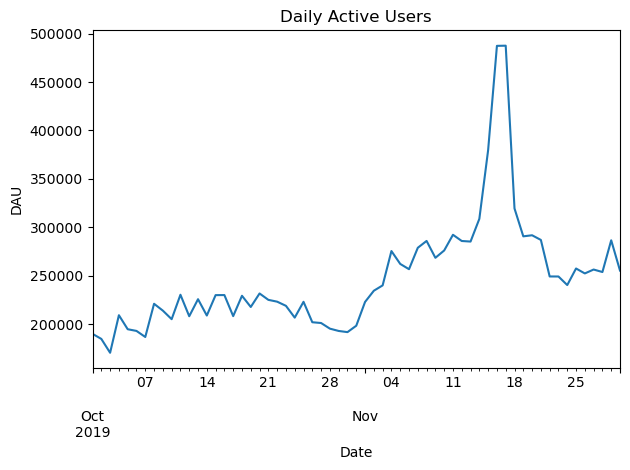

In [5]:
ax = dau.plot(x="event_date", y="dau", title="Daily Active Users", legend=False)
ax.set_xlabel("Date")
ax.set_ylabel("DAU")
plt.tight_layout()

## Takeaways

- Average DAU increased from **208,830 in October** to **287,381 in November**, suggesting higher product activity in November.
- Monthly active users were also higher in November: **3,695,321 MAU** versus **3,022,290 MAU** in October.
- DAU/MAU stickiness improved from **6.91% in October** to **7.78% in November**. This means the average daily audience became a slightly larger share of the monthly audience.
- Returning users became a larger part of weekly activity after the first observed week. For example, the week of **2019-11-11** had **955,350 returning users** versus **585,552 new users**.
- The strongest DAU day was **2019-11-17** with **487,501 active users**, **185,195 purchase events**, and **57.77M revenue**. This sits inside the known November 15-17 anomaly window, so it should be annotated before treating it as normal growth.
- The growth trend looks directionally positive, but November activity is partly distorted by the mid-November anomaly. Future analysis should compare metrics with and without the anomaly window before making product recommendations.

Overall, the product shows strong active-user scale and improving stickiness, but growth-health interpretation should separate normal engagement from anomaly-driven spikes.